In [1]:
video_path = "jomvids/yoyo.mp4"  # change this
motion_data_path = "testswings/jom2.xlsx"

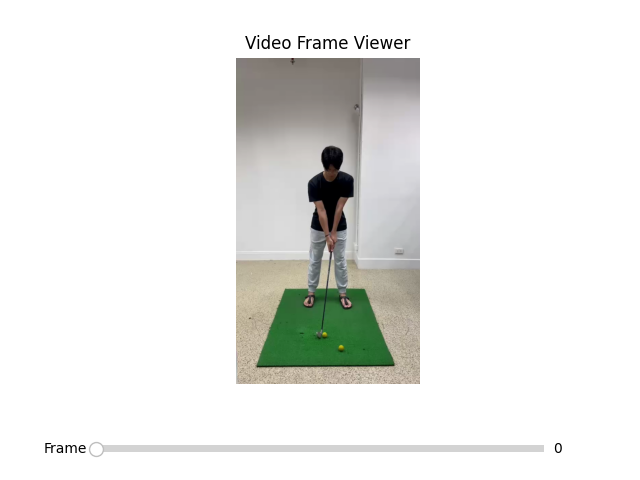

In [2]:
# Use the widget backend for interactive plots
%matplotlib widget
import cv2
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

# --- Load Video ---
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise FileNotFoundError(f'Cannot open video file: {video_path}')

frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
frames = []
success = True
while success:
    success, frame = cap.read()
    if success:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame_rgb)
cap.release()

# --- Create Figure ---
fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.2)

frame_img = ax.imshow(frames[0])
ax.axis("off")
ax.set_title("Video Frame Viewer")

# --- Slider Setup ---
slider_ax = plt.axes([0.15, 0.05, 0.7, 0.03])
frame_slider = Slider(
    ax=slider_ax,
    label="Frame",
    valmin=0,
    valmax=len(frames) - 1,
    valinit=0,
    valfmt="%0.0f",
)

def update_frame(val):
    idx = int(val)
    frame_img.set_data(frames[idx])
    fig.canvas.draw_idle()
    ax.set_title(f"Frame {idx} / {len(frames) - 1}")

frame_slider.on_changed(update_frame)

plt.show()

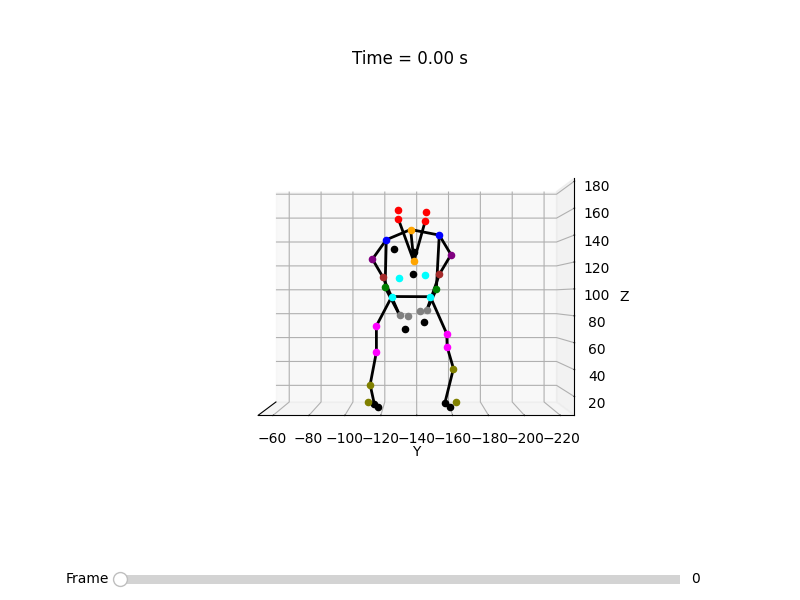

In [4]:
%matplotlib widget
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import numpy as np
from matplotlib.widgets import Slider

speed_factor = 5

# 1) Load & clean
df_raw = pd.read_excel(motion_data_path, header=1).iloc[:, 1:]
is_bone = df_raw.iloc[0] == "Bone Marker"
is_pos = df_raw.iloc[3] == "Position"
df_clean = df_raw.loc[:, is_bone & is_pos]
df_clean.columns = (
    df_clean.iloc[1].str.split(":").str[1] + "." + df_clean.iloc[4].astype(str)
)
df = df_clean.iloc[5:].reset_index(drop=True).astype(float)

marker_names = sorted({c.split(".")[0] for c in df.columns})
coords = {m: df[[f"{m}.X", f"{m}.Y", f"{m}.Z"]].values for m in marker_names}

# 2) Region & color maps
region_map = {
    "RFHD": "head", "LFHD": "head", "RBHD": "head", "LBHD": "head",
    "C7": "neck", "CLAV": "neck", "RFRM": "trunk", "LFRM": "trunk",
    "RSHO": "shoulder", "LSHO": "shoulder", "RUPA": "upper_arm", "LUPA": "upper_arm",
    "RELB": "elbow", "LELB": "elbow", "RWRA": "wrist", "LWRA": "wrist",
    "RWRB": "wrist", "LWRB": "wrist", "RASI": "pelvis", "LASI": "pelvis",
    "RPSI": "pelvis", "LPSI": "pelvis", "RTHI": "thigh", "LTHI": "thigh",
    "RKNE": "thigh", "LKNE": "thigh", "RTIB": "shin", "LTIB": "shin",
    "RANK": "shin", "LANK": "shin", "RHEE": "foot", "LHEE": "foot",
    "RTOE": "foot", "LTOE": "foot"
}
region_colors = {
    "head": "red", "neck": "orange", "trunk": "green", "shoulder": "blue",
    "upper_arm": "purple", "elbow": "brown", "wrist": "gray", "pelvis": "cyan",
    "thigh": "magenta", "shin": "olive", "foot": "black"
}

# 3) Set up 3D plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("3D Marker Animation")

# Hide X-axis
ax.set_xticks([])
ax.set_xlabel("")
try:
    ax.w_xaxis.line.set_color((0.0, 0.0, 0.0, 0.0))  # Older versions
except AttributeError:
    ax.xaxis.set_ticks([])
    ax.xaxis.set_ticklabels([])

scatters = {}
for m in marker_names:
    sec = region_map.get(m, None)
    color = region_colors.get(sec, "black")
    scatters[m] = ax.scatter([], [], [], s=20, color=color, label=m)

bones = [
    ("C7", "CLAV"), ("CLAV", "RFHD"), ("CLAV", "LFHD"), ("C7", "RSHO"),
    ("RSHO", "RUPA"), ("RUPA", "RELB"), ("RELB", "RWRB"), ("RSHO", "RFRM"),
    ("RFRM", "RWRB"), ("C7", "LSHO"), ("LSHO", "LUPA"), ("LUPA", "LELB"),
    ("LELB", "LWRB"), ("LSHO", "LFRM"), ("LFRM", "LWRB"), ("RASI", "LASI"),
    ("RASI", "RTHI"), ("RTHI", "RKNE"), ("RKNE", "RTIB"), ("RTIB", "RHEE"),
    ("LASI", "LTHI"), ("LTHI", "LKNE"), ("LKNE", "LTIB"), ("LTIB", "LHEE"),
]
lines = {}
for start, end in bones:
    (line,) = ax.plot([], [], [], linewidth=2, color="black")
    lines[(start, end)] = line

# equal axis limits
x_all = df[[f"{m}.X" for m in marker_names]].values.flatten()
y_all = df[[f"{m}.Y" for m in marker_names]].values.flatten()
z_all = df[[f"{m}.Z" for m in marker_names]].values.flatten()
x_min, x_max = np.nanmin(x_all), np.nanmax(x_all)
y_min, y_max = np.nanmin(y_all), np.nanmax(y_all)
z_min, z_max = np.nanmin(z_all), np.nanmax(z_all)
max_range = max(x_max - x_min, y_max - y_min, z_max - z_min) / 2
mid_x = (x_max + x_min) / 2
mid_y = (y_max + y_min) / 2
mid_z = (z_max + z_min) / 2
ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)
ax.view_init(elev=0, azim=180)  # YZ plane

# 4) Init & update
def init():
    for sc in scatters.values():
        sc._offsets3d = ([], [], [])
    for line in lines.values():
        line.set_data_3d([], [], [])
    return list(scatters.values()) + list(lines.values())

def update(frame):
    t = frame * 0.01
    for m, sc in scatters.items():
        x, y, z = coords[m][frame]
        sc._offsets3d = ([x], [y], [z])
    for (start, end), line in lines.items():
        x1, y1, z1 = coords[start][frame]
        x2, y2, z2 = coords[end][frame]
        line._verts3d = ([x1, x2], [y1, y2], [z1, z2])
    ax.set_title(f"Time = {t:.2f} s")
    return list(scatters.values()) + list(lines.values())

# 5) Slider for manual scrubbing
slider_ax = plt.axes([0.15, 0.02, 0.7, 0.03])
frame_slider = Slider(
    ax=slider_ax, label="Frame", valmin=0, valmax=len(df) - 1, valinit=0, valfmt="%0.0f"
)

def on_slider_change(val):
    update(int(val))
    fig.canvas.draw_idle()

frame_slider.on_changed(on_slider_change)

# draw first frame
init()
update(0)

# Show the interactive plot
plt.show()

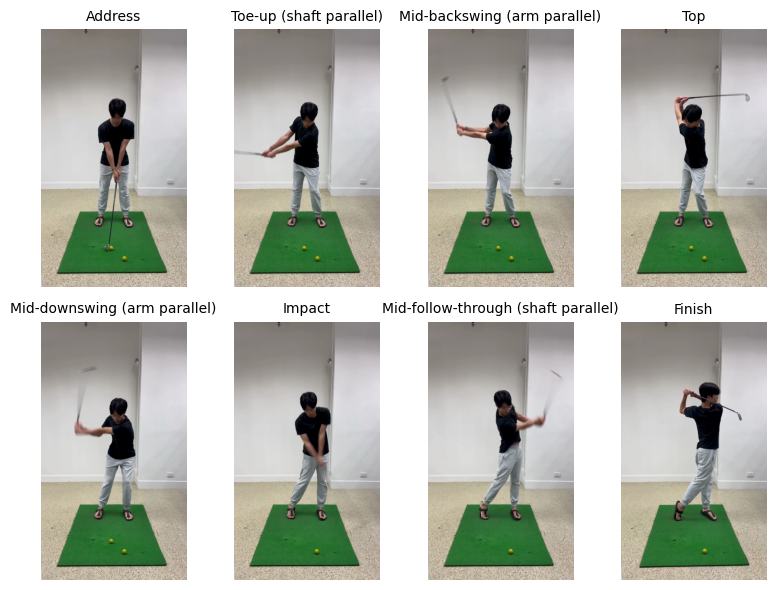

In [1]:
import cv2
import matplotlib.pyplot as plt

# 8 frame indices and their corresponding names
frame_indices = [0, 134, 138, 146, 153, 157, 160, 178]
event_names = {
    0: "Address",
    1: "Toe-up (shaft parallel)",
    2: "Mid-backswing (arm parallel)",
    3: "Top",
    4: "Mid-downswing (arm parallel)",
    5: "Impact",
    6: "Mid-follow-through (shaft parallel)",
    7: "Finish",
}

video_path = "jomvids/yoyo.mp4"

# Open video
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise FileNotFoundError(f"Cannot open video file: {video_path}")

# Grab frames
frames = []
for idx in frame_indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    success, frame = cap.read()
    if success:
        # convert to RGB for Matplotlib
        frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
cap.release()

# Plot in a 2×4 grid
fig, axs = plt.subplots(2, 4, figsize=(8, 6))
plt.subplots_adjust(hspace=0.4, wspace=0.4)

for i, ax in enumerate(axs.flat):
    ax.imshow(frames[i])
    ax.axis("off")
    ax.set_title(event_names[i], fontsize=10)

plt.tight_layout()
plt.show()

I0000 00:00:1747046306.754507 2625526 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M1 Pro
W0000 00:00:1747046306.830285 2632105 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1747046306.840837 2632105 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


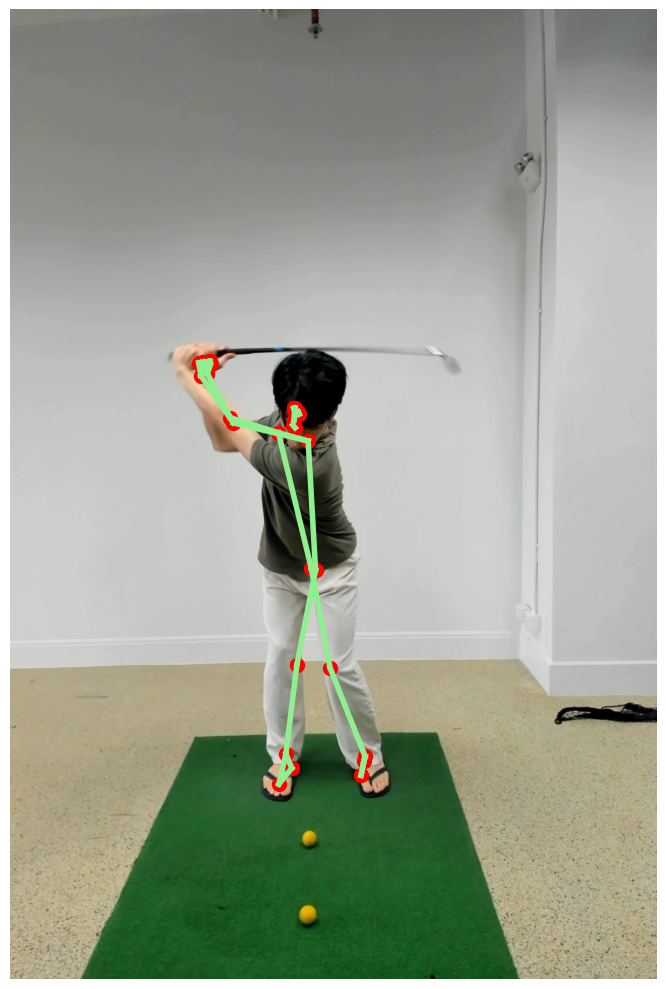

In [5]:
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

import matplotlib.pyplot as plt

# Initialize MediaPipe Pose Landmarker
BaseOptions = mp.tasks.BaseOptions
PoseLandmarker = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

# Create pose landmarker options
options = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path='./pose_landmarker_lite.task'),
    running_mode=VisionRunningMode.IMAGE,
    num_poses=1,
    min_pose_detection_confidence=0.5,
    min_pose_presence_confidence=0.5,
    min_tracking_confidence=0.5
)

# Load image
image_path = "image.jpeg"  # Change this to your image path
image = cv2.imread(image_path)
if image is None:
    raise FileNotFoundError(f"Cannot open image file: {image_path}")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Create pose landmarker and detect landmarks
with PoseLandmarker.create_from_options(options) as landmarker:
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
    detection_result = landmarker.detect(mp_image)

# Plot the image with landmarks
plt.figure(figsize=(10, 10))
plt.imshow(image_rgb)

# Draw landmarks
if detection_result.pose_landmarks:
    landmarks = detection_result.pose_landmarks[0]
    
    # Plot landmarks
    for landmark in landmarks:
        plt.plot(landmark.x * image_rgb.shape[1],
                 landmark.y * image_rgb.shape[0],
                 color='red', marker='o', linestyle='', markersize=10)
    
    # Draw connections
    connections = mp.solutions.pose.POSE_CONNECTIONS
    for connection in connections:
        start_idx = connection[0]
        end_idx = connection[1]
        
        if (start_idx < len(landmarks) and end_idx < len(landmarks)):
            start_point = landmarks[start_idx]
            end_point = landmarks[end_idx]
            
            plt.plot(
                [start_point.x * image_rgb.shape[1], end_point.x * image_rgb.shape[1]],
                [start_point.y * image_rgb.shape[0], end_point.y * image_rgb.shape[0]],
                color='lightgreen', linewidth=4
            )

# plt.title("MediaPipe Pose Landmarks")
plt.axis('off')
plt.tight_layout()
plt.show()